<a href="https://colab.research.google.com/github/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/blob/main/AULA_06_SERS_ML_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EXERCÍCIO

Treinar um modelo preditivo de classificação binária. O modelo fará as previsões com base nos dados da coluna 'stabf' mostrando se a rede elétrica está INSTÁVEL ou ESTÁVEL. Utilizar o algoritmo Regressão Logística (Logistic Regression do sklearn) para o treinamento do modelo. Avaliar o modelo com base na acurácia. Apresentar a Matriz de Confusão.


##PREPARAÇÃO DO AMBIENTE

In [1]:
# Manipulação de tabelas e matrizes/vetores
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão logística
from sklearn.linear_model import LogisticRegression
# Ferramenta para separação dos dados de treino e teste
# X_train, X_test, y_train, y_test
from sklearn.model_selection import train_test_split
# Avaliação com acurácia e matriz de confusão
from sklearn.metrics import accuracy_score, confusion_matrix

## CARREGAR OS DADOS E CRIAR O DATAFRAME


In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_1CCPH_SERS/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## REALIZAR A INSPEÇÃO BÁSICA DOS DADOS

In [3]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


In [7]:
# Número de registros
dados.shape[0]

10000

In [4]:
# Quantas classes existem na coluna 'stabf'?
dados['stabf'].unique()

<StringArray>
['unstable', 'stable']
Length: 2, dtype: str

In [5]:
# Quantos registros existem de cada classe na coluna 'stabf'?
dados['stabf'].value_counts()

stabf
unstable    6380
stable      3620
Name: count, dtype: int64

In [6]:
# Estatísticas descritivas
# Para atributos categóricos
dados.describe(include='object')

/var/folders/y1/3n961y915fd02sd1qrhqxss00000gn/T/ipykernel_49365/1131473345.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dados.describe(include='object')


,stabf
count,10000
unique,2
top,unstable
freq,6380


In [7]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='str')

## SEPARAÇÃO DE DADOS DE ENTRADA (FEATURES) E DADOS DE SAÍDA (TARGET)

In [8]:
# Features ---> características que o modelo recebe para aprender os padrões no treino
# X (maiúsculo) -----> variáveis independentes ---> FEATURES ----> DataFrame com dados de entrada
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [9]:
dados['stabf'] = dados['stabf'].replace({'unstable': 'INSTÁVEL', 'stable': 'ESTÁVEL'})
dados['stabf'].value_counts()

stabf
INSTÁVEL    6380
ESTÁVEL     3620
Name: count, dtype: int64

In [10]:
# Target -----> atributo que será previsto pelo modelo
# y (minúsculo) ----> variável dependente --------> TARGET -----> array numpy com dados da coluna 'stabf'
y = dados['stabf']
y

0       INSTÁVEL
1        ESTÁVEL
2       INSTÁVEL
3       INSTÁVEL
4       INSTÁVEL
          ...   
9995    INSTÁVEL
9996     ESTÁVEL
9997     ESTÁVEL
9998    INSTÁVEL
9999    INSTÁVEL
Name: stabf, Length: 10000, dtype: str

## SEPARAÇÃO DE DADOS DE TREINO E TESTE

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Total de registros ----> 10.000
X.shape[0]

10000

In [13]:
X_train.shape[0]

8000

In [14]:
X_test.shape[0]

2000

## TREINAMENTO, GERAÇÃO DE PREVISÕES E AVALIAÇÃO DO MODELO

In [15]:
# Instanciando o modelo
modelo = LogisticRegression()

In [16]:
# Treinamento
modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [17]:
# Gerar o array com as probabilidades
probabilidades = modelo.predict_proba(X_test)
probabilidades[:20]

array([[0.04609348, 0.95390652],
       [0.06082634, 0.93917366],
       [0.31665189, 0.68334811],
       [0.97845447, 0.02154553],
       [0.64488737, 0.35511263],
       [0.57310264, 0.42689736],
       [0.7293308 , 0.2706692 ],
       [0.0220369 , 0.9779631 ],
       [0.04455238, 0.95544762],
       [0.74263825, 0.25736175],
       [0.05821672, 0.94178328],
       [0.43539611, 0.56460389],
       [0.54821046, 0.45178954],
       [0.22628137, 0.77371863],
       [0.01738045, 0.98261955],
       [0.24059749, 0.75940251],
       [0.43383254, 0.56616746],
       [0.19235057, 0.80764943],
       [0.42956875, 0.57043125],
       [0.30915071, 0.69084929]])

In [18]:
# Gerar array de previsões
y_predict = modelo.predict(X_test)
y_predict[:20]

array(['INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL'],
      dtype=object)

In [19]:
# Avaliar com base na acurácia
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A acurácia do modelo é de {acuracia:.2f}%')

A acurácia do modelo é de 81.70%


In [ ]:
# Gerar matriz de confusão com matplotlib e heatmap

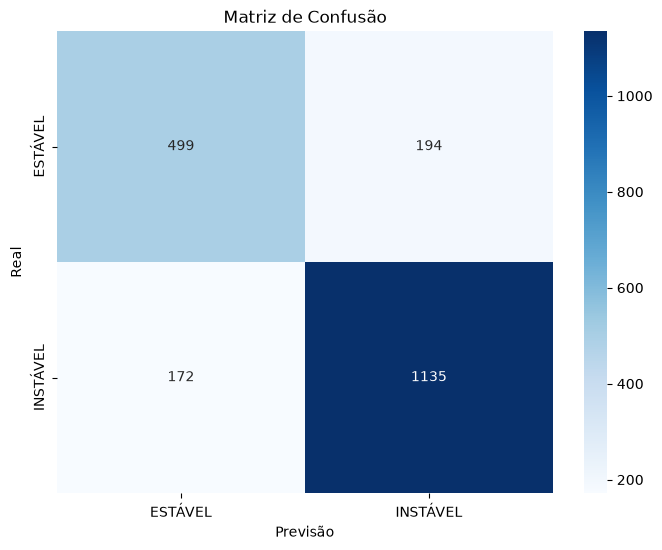

In [20]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ESTÁVEL', 'INSTÁVEL'], yticklabels=['ESTÁVEL', 'INSTÁVEL'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()